In [ ]:
pip install yfinance pandas


In [ ]:
import yfinance as yf
import pandas as pd
from datetime import datetime

**Stock Price**

In [ ]:
import yfinance as yf
import pandas as pd
from datetime import datetime

# FTSE 100 sample tickers with '.L' suffix for London Stock Exchange
tickers = ['HSBA.L', 'BP.L', 'AZN.L', 'GSK.L', 'VOD.L']

# Date range
start_date = "2020-01-01"
end_date = datetime.today().strftime('%Y-%m-%d')

# Download all data at once
data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    group_by='ticker',
    auto_adjust=True,
    progress=False
)

# Initialize list to hold cleaned dataframes
dfs = []

# Loop through each ticker's data
for ticker in tickers:
    try:
        ticker_df = data[ticker].copy()
        ticker_df['Date'] = ticker_df.index
        ticker_df['Ticker'] = ticker
        dfs.append(ticker_df.reset_index(drop=True))
    except KeyError:
        print(f" Data not found for: {ticker}")

# Combine all into a single DataFrame
stock_df = pd.concat(dfs, ignore_index=True)

# Optional: drop NaNs and sort
stock_df.dropna(inplace=True)
stock_df.sort_values(by=['Ticker', 'Date'], inplace=True)

# Display sample
print(f"Final dataset shape: {stock_df.shape}")
print(stock_df.head())
print(stock_df['Ticker'].unique())


Final dataset shape: (6779, 7)
Price         Open         High          Low        Close     Volume  \
2712   7584.778397  7659.677460  7554.818772  7649.690918  1704325.0   
2713   7614.738627  7689.637695  7570.717870  7689.637695  1090818.0   
2714   7658.679306  7669.664502  7535.844835  7612.741211  1348181.0   
2715   7597.760734  7654.684020  7552.821298  7634.710938  1308820.0   
2716   7606.748929  7658.678946  7568.800070  7615.736816  1256533.0   

Price       Date Ticker  
2712  2020-01-02  AZN.L  
2713  2020-01-03  AZN.L  
2714  2020-01-06  AZN.L  
2715  2020-01-07  AZN.L  
2716  2020-01-08  AZN.L  
['AZN.L' 'BP.L' 'GSK.L' 'HSBA.L' 'VOD.L']


**Exchange Rate**

In [ ]:
fx_data = yf.download("GBPUSD=X", start="2015-01-01", end=datetime.today().strftime('%Y-%m-%d'))
fx_data.to_csv("GBPUSD_data.csv")


[*********************100%***********************]  1 of 1 completed


In [ ]:

fx_data = pd.read_csv('/content/GBPUSD_data.csv',skiprows=3)

fx_data.columns = ["Date","Close","High","Low","Open","Volume"]
fx_data.set_index('Date', inplace=True)

fx_data = fx_data[['Close']].rename(columns={'Close': 'GBP/USD'})
fx_data.reset_index(inplace=True)
print(fx_data.head())



         Date   GBP/USD
0  2015-01-02  1.557972
1  2015-01-05  1.528491
2  2015-01-06  1.525832
3  2015-01-07  1.513798
4  2015-01-08  1.510757


**Inflation Rate**

In [ ]:
import pandas as pd

# Load the file with the correct number of columns
cpi_raw = pd.read_csv('/content/cpih01-time-series-v57.csv')

# Check the unique CPI codes
print(cpi_raw['cpih1dim1aggid'].unique())

print(cpi_raw['cpih1dim1aggid'].value_counts())

['CP0122' 'CP0115' 'CP0212' 'CP03' 'CP0314' 'CP04' 'CP05' 'CP0512'
 'CP0622' 'CP0732_0736' 'CP082_083' 'CP0912' 'CP1211' 'CP1212_1213'
 'CP124' 'CP0121' 'CP045' 'CP0452' 'CP0561' 'CP061' 'CP0712_0713' 'CP09'
 'CP0913' 'CP0942' 'CP112' 'CP127' 'CP0933' 'CP00' 'CP0441' 'CP0934_0935'
 'CP0721' 'CP11' 'CP1111' 'CP095' 'CP1231' 'CP0952' 'CP1252' 'CP051'
 'CP042' 'CP06' 'CP053' 'CP111' 'CP0612_0613' 'CP062' 'CP073' 'CP0914'
 'CP0711N1' 'CP0722' 'CP0723' 'CP0953_0954' 'CP091' 'CP12' 'CP092'
 'CP0951' 'CP1254' 'CP126' 'CP0112' 'CP0113' 'CP043' 'CP0431' 'CP0443'
 'CP0511' 'CP0531_0532' 'CP0533' 'CP0611' 'CP0911' 'CP094' 'CP123'
 'CP1232' 'CP0119' 'CP0312' 'CP032' 'CP041' 'CP044' 'CP0451' 'CP063'
 'CP071' 'CP012' 'CP0213' 'CP022' 'CP049' 'CP054' 'CP0562' 'CP0621_0623'
 'CP072' 'CP0724' 'CP0731' 'CP0733' 'CP0932' 'CP1253' 'CP0116' 'CP02'
 'CP0111' 'CP011' 'CP0114' 'CP0118' 'CP0432' 'CP0454' 'CP0313' 'CP0117'
 'CP021' 'CP0211' 'CP01' 'CP0453' 'CP031' 'CP052' 'CP055' 'CP056' 'CP07'
 'CP0711N2' 'CP0

In [ ]:
import pandas as pd

# Load raw CPI
cpi_raw = pd.read_csv("/content/cpih01-time-series-v57.csv")

# Convert 'Time' to datetime (monthly frequency)
cpi_raw['Date'] = pd.to_datetime(cpi_raw['Time'], format='%b-%y', errors='coerce')

cpi_main = cpi_raw[cpi_raw['cpih1dim1aggid'] == 'CP00']

# Rename and format
cpi_main = cpi_main[['Time', 'v4_0']].copy()
cpi_main.columns = ['Date', 'CPI']
cpi_main['Date'] = pd.to_datetime(cpi_main['Date'], format='%b-%y')
cpi_main['CPI'] = pd.to_numeric(cpi_main['CPI'], errors='coerce')

# Resample to daily and forward fill
cpi_daily = cpi_main.set_index('Date').resample('D').ffill().reset_index()
print(cpi_daily.tail())


            Date    CPI
13570 2025-02-25  135.6
13571 2025-02-26  135.6
13572 2025-02-27  135.6
13573 2025-02-28  135.6
13574 2025-03-01  136.1


**Bank Base rate of Interest**

In [ ]:
# Load Bank Rate CSV
rate_df = pd.read_csv('/content/Bank Rate history and data  Bank of England Database.csv')
print(rate_df.head())

# Rename columns
rate_df.columns = ['Date Changed', 'Rate']
rate_df['Date'] = pd.to_datetime(rate_df['Date Changed'], errors='coerce')
rate_df.dropna(inplace=True)

# Convert to daily and fill missing values
rate_daily = rate_df.set_index('Date').resample('D').ffill().reset_index()

print(rate_daily.tail())


  Date Changed  Rate
0    08 May 25  4.25
1    06 Feb 25  4.50
2    07 Nov 24  4.75
3    01 Aug 24  5.00
4    03 Aug 23  5.25
            Date Date Changed  Rate
18367 2025-05-04    06 Feb 25  4.50
18368 2025-05-05    06 Feb 25  4.50
18369 2025-05-06    06 Feb 25  4.50
18370 2025-05-07    06 Feb 25  4.50
18371 2025-05-08    08 May 25  4.25


<ipython-input-135-6ab110eedec4>:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rate_df['Date'] = pd.to_datetime(rate_df['Date Changed'], errors='coerce')


**Unemployment Data**

In [ ]:
import pandas as pd

# Load the raw unemployment file
df = pd.read_csv("/content/Unemployment_series-180525.csv", skiprows=8)
df.columns = ["Date", "UnemploymentRate"]
print(df.head())

# Keep only monthly data (rows where the date contains a month abbreviation, e.g., 'FEB')
df_monthly = df[df['Date'].str.len() == 8]  # e.g., '1971 FEB' is 8 chars
print(df_monthly.head())
# Convert to datetime
df_monthly['Date'] = pd.to_datetime(df_monthly['Date'], format="%Y %b")

# Optional: sort and reset index
df_monthly = df_monthly.sort_values('Date').reset_index(drop=True)
print(df_monthly.head())
# Save cleaned file
df_monthly.to_csv("unemployment_monthly_cleaned.csv", index=False)


   Date  UnemploymentRate
0  1972               4.3
1  1973               3.7
2  1974               3.7
3  1975               4.5
4  1976               5.4
         Date  UnemploymentRate
270  1971 FEB               3.8
271  1971 MAR               3.9
272  1971 APR               4.0
273  1971 MAY               4.1
274  1971 JUN               4.1
        Date  UnemploymentRate
0 1971-02-01               3.8
1 1971-03-01               3.9
2 1971-04-01               4.0
3 1971-05-01               4.1
4 1971-06-01               4.1


<ipython-input-136-ca0368c504d1>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_monthly['Date'] = pd.to_datetime(df_monthly['Date'], format="%Y %b")


In [ ]:
import pandas as pd

# Load the dataset
unemployment_df = pd.read_csv('unemployment_monthly_cleaned.csv')

unemployment_df['Date'] = pd.to_datetime(unemployment_df['Date'])
print(unemployment_df.head())

unemployment_daily = unemployment_df.set_index('Date').resample('D').ffill().reset_index()
print(unemployment_daily.head())

unemployment_daily.sort_values('Date', inplace=True)


        Date  UnemploymentRate
0 1971-02-01               3.8
1 1971-03-01               3.9
2 1971-04-01               4.0
3 1971-05-01               4.1
4 1971-06-01               4.1
        Date  UnemploymentRate
0 1971-02-01               3.8
1 1971-02-02               3.8
2 1971-02-03               3.8
3 1971-02-04               3.8
4 1971-02-05               3.8


In [ ]:
print(stock_df.head())
print(cpi_daily.head())
print(rate_daily.head())
print(fx_data.head())
print(unemployment_daily.head())


Price         Open         High          Low        Close     Volume  \
2712   7584.778397  7659.677460  7554.818772  7649.690918  1704325.0   
2713   7614.738627  7689.637695  7570.717870  7689.637695  1090818.0   
2714   7658.679306  7669.664502  7535.844835  7612.741211  1348181.0   
2715   7597.760734  7654.684020  7552.821298  7634.710938  1308820.0   
2716   7606.748929  7658.678946  7568.800070  7615.736816  1256533.0   

Price       Date Ticker  
2712  2020-01-02  AZN.L  
2713  2020-01-03  AZN.L  
2714  2020-01-06  AZN.L  
2715  2020-01-07  AZN.L  
2716  2020-01-08  AZN.L  
        Date   CPI
0 1988-01-01  46.9
1 1988-01-02  46.9
2 1988-01-03  46.9
3 1988-01-04  46.9
4 1988-01-05  46.9
        Date Date Changed   Rate
0 1975-01-20    20 Jan 75  11.25
1 1975-01-21    20 Jan 75  11.25
2 1975-01-22    20 Jan 75  11.25
3 1975-01-23    20 Jan 75  11.25
4 1975-01-24    20 Jan 75  11.25
         Date   GBP/USD
0  2015-01-02  1.557972
1  2015-01-05  1.528491
2  2015-01-06  1.525832
3  

**Merging all dataframes**

In [ ]:

for df in [stock_df, cpi_daily, rate_daily, unemployment_df, fx_data]:
    df['Date'] = pd.to_datetime(df['Date'])


# Sort all dataframes
stock_df = stock_df.sort_values('Date')
cpi_daily = cpi_daily.sort_values('Date')
rate_daily = rate_daily.sort_values('Date')
unemployment_df = unemployment_df.sort_values('Date')
fx_data = fx_data.sort_values('Date')

merge_df=pd.DataFrame()

# Merge CPI
merge_df = pd.merge_asof(stock_df, cpi_daily, on='Date')

# Merge Interest Rate
merge_df = pd.merge_asof(merge_df, rate_daily[['Date', 'Rate']], on='Date')

# Merge Unemployment
merge_df = pd.merge_asof(merge_df, unemployment_df, on='Date')

# Merge FX
merge_df = pd.merge_asof( merge_df.sort_values('Date'), fx_data.sort_values('Date'))




**Time Series Plots**

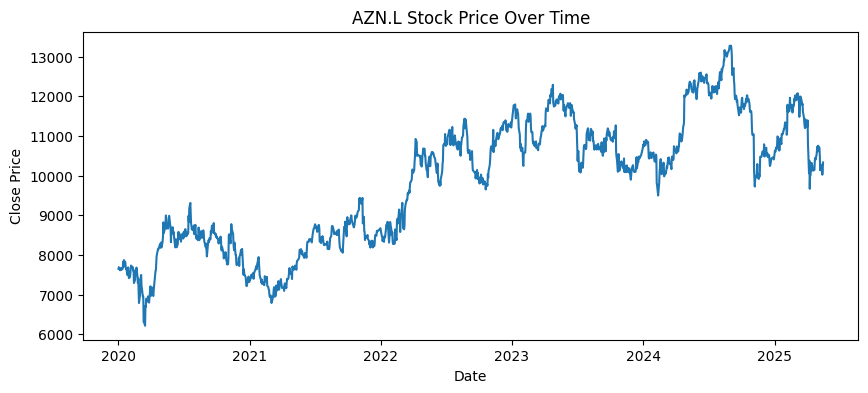

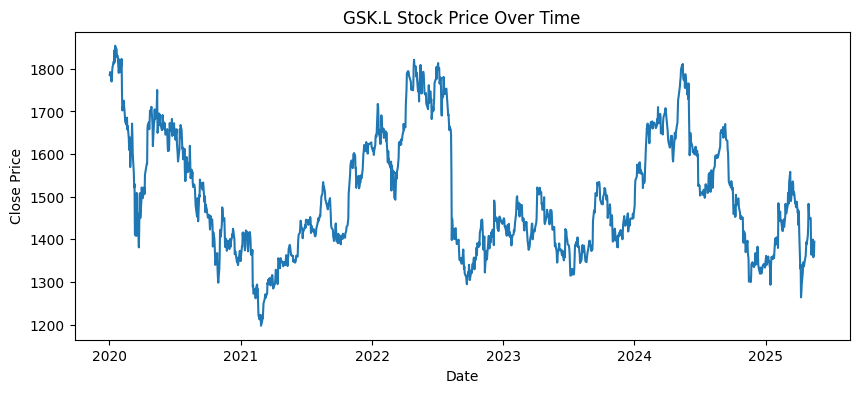

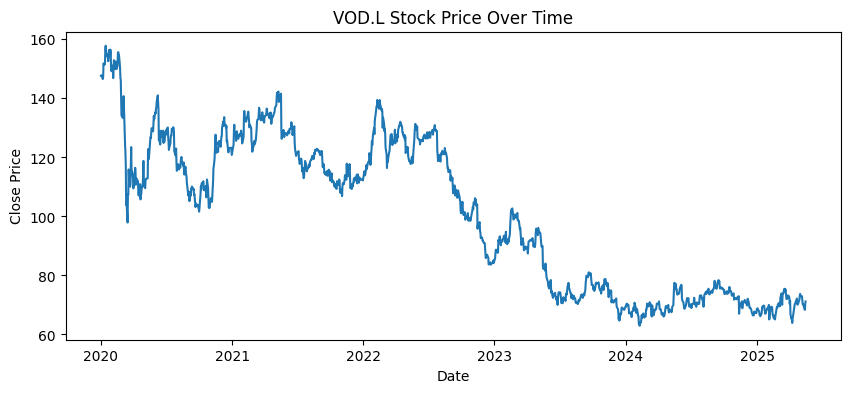

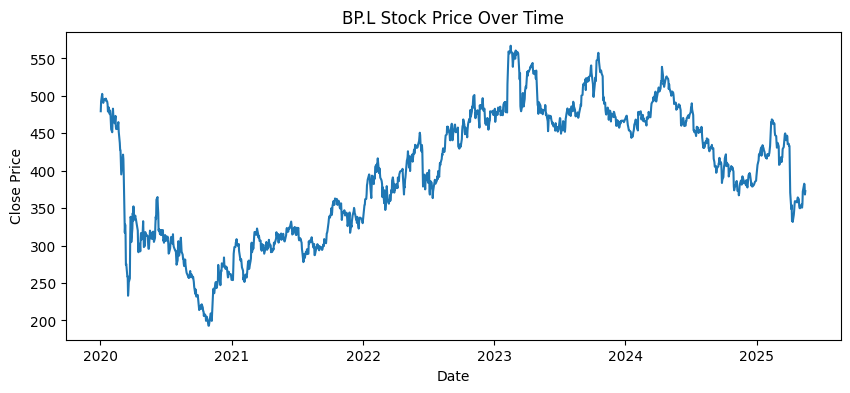

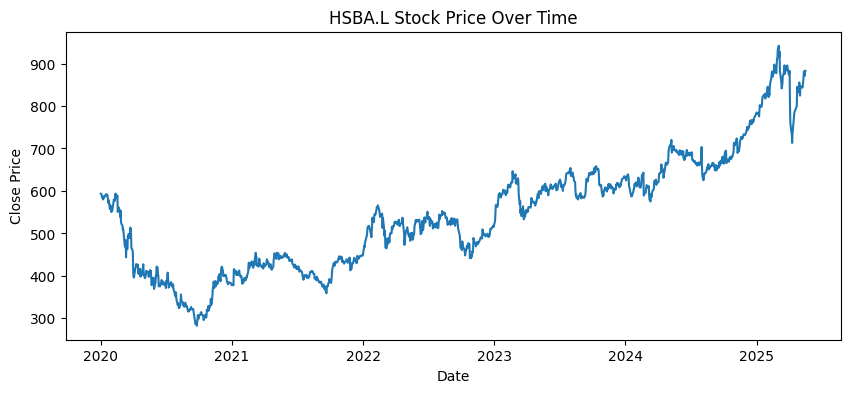

In [ ]:
import matplotlib.pyplot as plt

# Stock Price over time
for ticker in merge_df['Ticker'].unique():
    plt.figure(figsize=(10, 4))
    plt.plot(merge_df[merge_df['Ticker'] == ticker]['Date'],
             merge_df[merge_df['Ticker'] == ticker]['Close'])
    plt.title(f"{ticker} Stock Price Over Time")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.show()


**Macroeconomic Trend Overview**

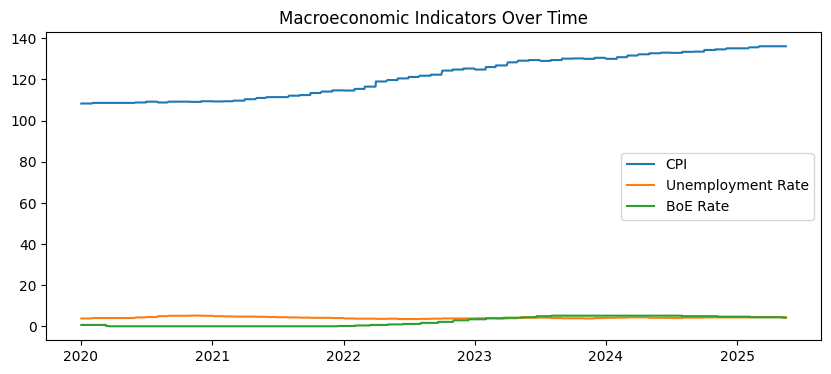

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(merge_df['Date'], merge_df['CPI'], label='CPI')
plt.plot(merge_df['Date'], merge_df['UnemploymentRate'], label='Unemployment Rate')
plt.plot(merge_df['Date'], merge_df['Rate'], label='BoE Rate')
plt.legend()
plt.title("Macroeconomic Indicators Over Time")
plt.show()


**Correlation Heatmap**

<Axes: >

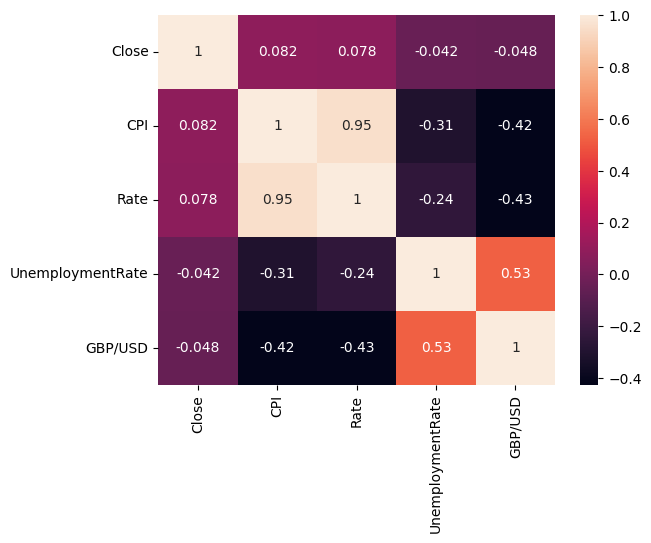

In [ ]:
import seaborn as sns
sns.heatmap(merge_df[['Close', 'CPI', 'Rate', 'UnemploymentRate', 'GBP/USD']].corr(), annot=True)
